In [ ]:
#Transferencia de Aprendizaje / Transfer Learning

In [ ]:
#Crear nuestro propio conjunto de datos

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# REINICIAR DESDE AQUÍ SI YA SE CARGARON LAS IMÁGENES
#Aumento de datos
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

#Crear el dataset generador
datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range = 10,
    width_shift_range=0.15,
    height_shift_range = 0.15,
    shear_range = 5,
    zoom_range = [0.7, 1.3],
    validation_split = 0.2
)

data_gen_entrenamiento = datagen.flow_from_directory("dataset",
                                                     target_size=(224,224),
                                                     batch_size=32, shuffle=True,
                                                     subset="training")

data_gen_pruebas = datagen.flow_from_directory("dataset",
                                                     target_size=(224,224),
                                                     batch_size=32, shuffle=True,
                                                     subset="validation")

Found 864 images belonging to 4 classes.
Found 216 images belonging to 4 classes.


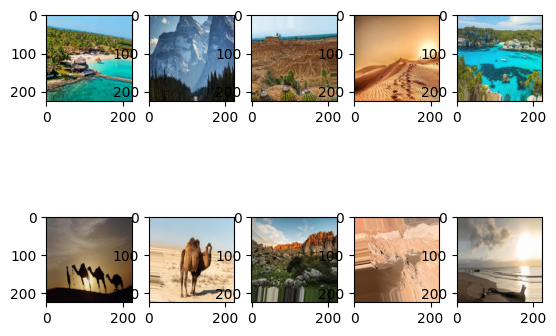

In [3]:
import matplotlib.pyplot as plt

for imagenes, etiquetas in data_gen_entrenamiento:
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(imagenes[i])
        # plt.axis("off")
    break

plt.show()


In [12]:
import tensorflow as tf
import tensorflow_hub as hub

url ="https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

In [13]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"   # 👈 equivale a feature_vector
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
outputs = tf.keras.layers.Dense(4, activation="softmax")(x)

modelo = tf.keras.Model(inputs, outputs)

In [14]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
EPOCAS = 100
entrenamiento = modelo.fit(
    data_gen_entrenamiento, epochs=EPOCAS, batch_size=32,
    validation_data=data_gen_pruebas
)
modelo.save("modelo_clasificador_playa_desierto_montana.keras")

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 454ms/step - accuracy: 0.6715 - loss: 0.8098 - val_accuracy: 0.6852 - val_loss: 0.7995
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 427ms/step - accuracy: 0.7069 - loss: 0.7184 - val_accuracy: 0.7269 - val_loss: 0.7691
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 431ms/step - accuracy: 0.7601 - loss: 0.6852 - val_accuracy: 0.7315 - val_loss: 0.6965
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 429ms/step - accuracy: 0.7704 - loss: 0.6347 - val_accuracy: 0.7685 - val_loss: 0.6368
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 428ms/step - accuracy: 0.7904 - loss: 0.6051 - val_accuracy: 0.7269 - val_loss: 0.6440
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 430ms/step - accuracy: 0.7921 - loss: 0.5456 - val_accuracy: 0.7917 - val_loss: 0.5834
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 428ms/step - accuracy: 0.8420 - loss: 0.4750 - val_accuracy: 0.8009 - val_loss: 0.5592
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 425ms/step - accuracy: 0.8548 - loss: 0.4627 - 

In [17]:
print(data_gen_entrenamiento.class_indices)

{'.ipynb_checkpoints': 0, 'desierto': 1, 'montana': 2, 'playa': 3}


In [18]:
import numpy as np
from PIL import Image

CLASES = ["nada", "desierto", "montana", "playa"]

def categorizar(ruta):
    img = Image.open(ruta).convert("RGB")
    img = img.resize((224, 224))
    img = np.array(img).astype("float32") / 255.0

    img = np.expand_dims(img, axis=0)  # (1, 224, 224, 3)
    pred = modelo.predict(img, verbose=0)[0]

    indice = np.argmax(pred)
    etiqueta = CLASES[indice]
    confianza = pred[indice]

    return etiqueta, float(confianza)

Predicción: desierto
Confianza: 99.94%


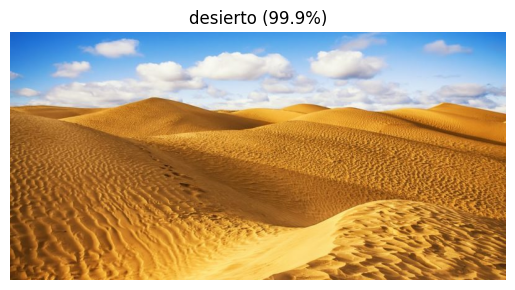

In [19]:
import matplotlib.pyplot as plt

ruta = "desierto-test.jpg"
img = Image.open(ruta)

etiqueta, confianza = categorizar(ruta)

print(f"Predicción: {etiqueta}")
print(f"Confianza: {confianza:.2%}")

plt.imshow(img)
plt.axis("off")
plt.title(f"{etiqueta} ({confianza:.1%})")
plt.show()


Predicción: montana
Confianza: 99.19%


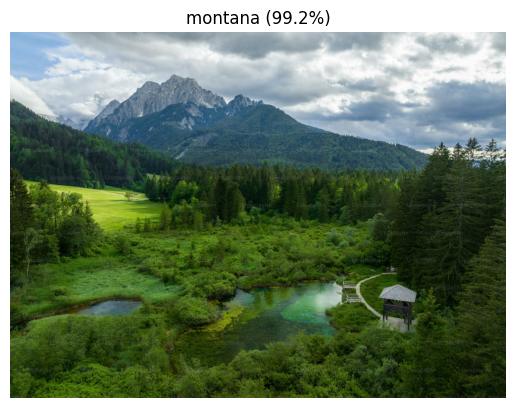

In [20]:
ruta = "montana-test.jpg"
img = Image.open(ruta)

etiqueta, confianza = categorizar(ruta)

print(f"Predicción: {etiqueta}")
print(f"Confianza: {confianza:.2%}")

plt.imshow(img)
plt.axis("off")
plt.title(f"{etiqueta} ({confianza:.1%})")
plt.show()

Predicción: playa
Confianza: 99.98%


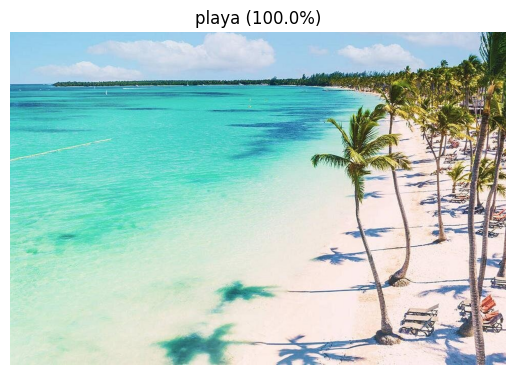

In [21]:
ruta = "playa-test.jpg"
img = Image.open(ruta)

etiqueta, confianza = categorizar(ruta)

print(f"Predicción: {etiqueta}")
print(f"Confianza: {confianza:.2%}")

plt.imshow(img)
plt.axis("off")
plt.title(f"{etiqueta} ({confianza:.1%})")
plt.show()